## VOCs (Volatile Organic Compounds)

In the current model (`2025-11-05 Temperature and pressure dependent box model.ipynb`), some parts showed fairly good agreement between modelled and measured OH; other parts overestimated OH by 3-4 times - see figure from notebook:

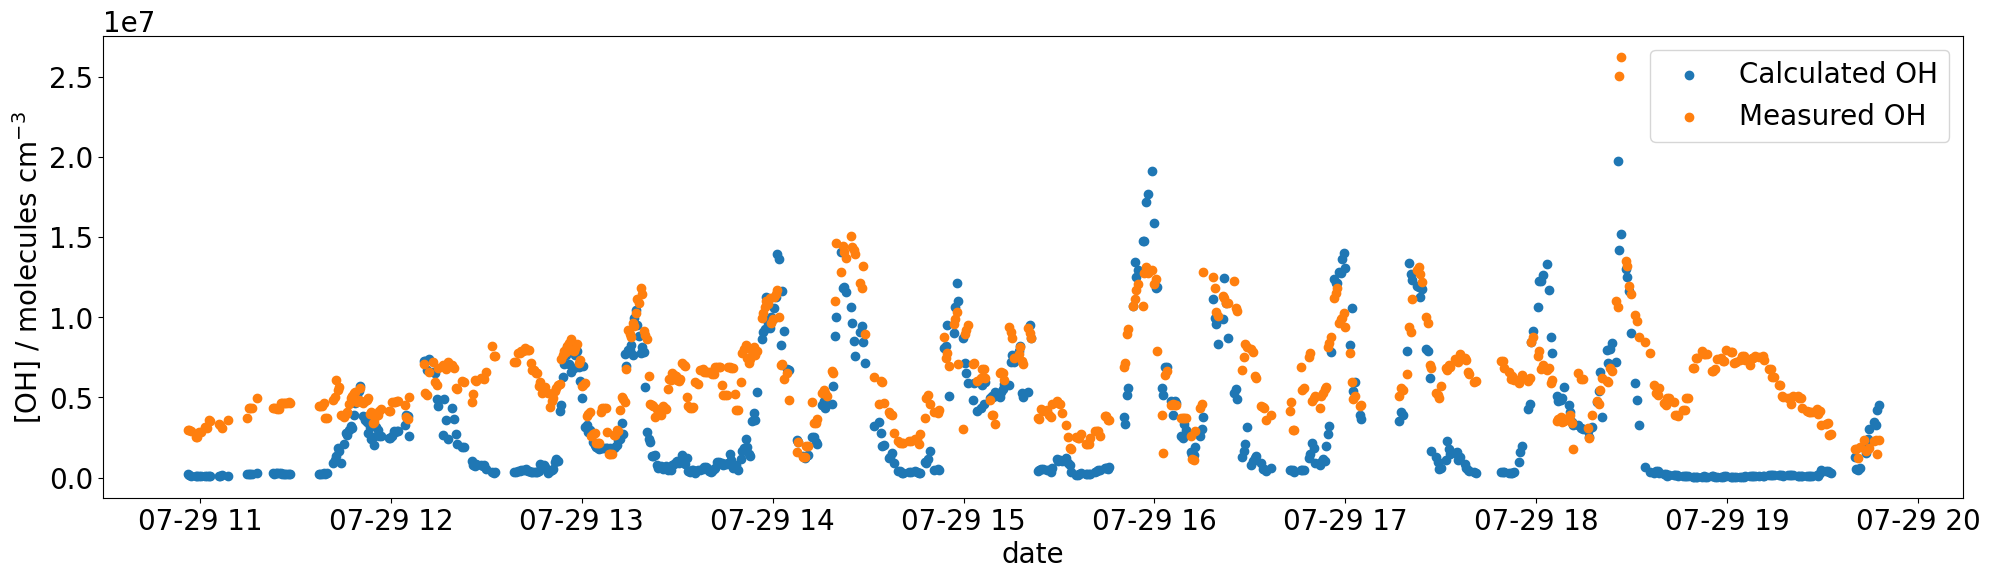

In [1]:
import pickle

with open("comparison.pkl", "rb") as f:
    fig = pickle.load(f)

fig.show()

The reason for this can be because of overestimation of OH sources, or missing OH sinks (probably both). Equifinality

VOCs are important sinks for OH and the model did not consider what VOCs might be present. Can have a looking at what VOCs are present in the dataframe and how much each contributes to the loss rate.

In [2]:
import pandas as pd
df = pd.read_csv("MDS_atom1_2016_summer_with_no_no2_oh_ho2_full_js.csv")
from datetime import datetime, timezone
from pytz import timezone
df["UTC_Start_dt"] = pd.to_datetime(df["UTC_Start_dt"])
df['UTC_Start_dt'] = df['UTC_Start_dt'].dt.tz_localize('UTC')
df["UTC_Start_dt"] = df["UTC_Start_dt"].dt.tz_convert('America/New_York')
df['date'] = df['UTC_Start_dt']

In [3]:
df.head()

,Unnamed: 0,UTC_Start_dt,ATom_parcel,Start_UTC,Date,Research Flight Number,Latitude,Longitude,Altitude,Pres,...,jNO3_NO2_O3P_CAFS,jNO3_NO_O2_CAFS,jO3_O2_O1D_CAFS,jO3_dnwFrac_CAFS,jPAN_CH3COO2_NO2_CAFS,jPAN_CH3COO_NO3_CAFS,jPropanal_CH2CH3_HCO_CAFS,lat,lon,date
0,121,2016-07-29 10:56:10-04:00,1000122,53770,20160729,1,33.01171,-118.89800,8804.58,343.334,...,0.210835,0.025632,0.000009,0.703450,2.479964e-07,1.062842e-07,0.000018,33.01171,241.10200,2016-07-29 10:56:10-04:00
1,124,2016-07-29 10:56:40-04:00,1000125,53800,20160729,1,32.96985,-118.95240,8931.10,337.478,...,0.212448,0.025815,0.000009,0.702175,2.504532e-07,1.073371e-07,0.000018,32.96985,241.04760,2016-07-29 10:56:40-04:00
2,127,2016-07-29 10:57:10-04:00,1000128,53830,20160729,1,32.92798,-119.00677,9057.14,331.741,...,0.214809,0.026108,0.000009,0.696450,2.547722e-07,1.091881e-07,0.000019,32.92798,240.99323,2016-07-29 10:57:10-04:00
3,136,2016-07-29 10:58:40-04:00,1000137,53920,20160729,1,32.80281,-119.16970,9425.14,315.391,...,0.221572,0.026932,0.000010,0.690775,2.613555e-07,1.120095e-07,0.000020,32.80281,240.83030,2016-07-29 10:58:40-04:00
4,139,2016-07-29 10:59:10-04:00,1000140,53950,20160729,1,32.76114,-119.22341,9550.39,309.998,...,0.223360,0.027156,0.000010,0.689000,2.626297e-07,1.125556e-07,0.000021,32.76114,240.77659,2016-07-29 10:59:10-04:00


In [4]:
print(df.columns.values)

['Unnamed: 0' 'UTC_Start_dt' 'ATom_parcel' 'Start_UTC' ' Date'
 ' Research Flight Number' 'Latitude' 'Longitude' 'Altitude' 'Pres' 'Temp'
 'SpecHum' 'H2O_M' 'RHw' 'O3_M' 'CO_M' 'CH4_M' 'NOX_M' 'HNO3_M' 'HNO4_M'
 'PAN_M' 'HCHO_M' 'H2O2_M' 'CH3OOH_M' ' Acetone_M' ' Acetald_M' ' C2H6_M'
 ' C3H8_M' 'iC4H10_M' ' nC4H10_M' ' Alkanes_M' ' C2H4_M' ' Alkenes_M'
 'C2H2_M' ' C5H8_M' ' Benzene_M' ' Toluene_M' ' Xylene_M' 'MeONO2_M'
 ' EtONO2_M' ' RONO2_M' ' MeOH_M' ' HCN_M' ' CH3CN_M' 'SF6_M' ' S_nuc_M'
 ' S_atk_M' ' S_acc_M' ' S_crs_M' ' CloudInd_M' 'Flag_H2O_M' 'Flag_RHw'
 'Flag_O3_M' 'Flag_CO_M' 'Flag_CH4_M' 'Flag_NOX_M' 'Flag_PSSNOX_M'
 'Flag_HNO3_M' 'Flag_HNO4_M' 'Flag_PAN_M' 'Flag_HCHO_M' 'Flag_H2O2_M'
 'Flag_CH3OOH_M' ' Flag_Acetone_M' ' Flag_Acetald_M' ' Flag_C2H6_M'
 ' Flag_C3H8_M' 'Flag_iC4H10_M' ' Flag_nC4H10_M' ' Flag_Alkanes_M'
 ' Flag_C2H4_M' ' Flag_Alkenes_M' 'Flag_C2H2_M' ' Flag_C5H8_M'
 ' Flag_Benzene_M' ' Flag_Toluene_M' ' Flag_Xylene_M' 'Flag_MeONO2_M'
 ' Flag_EtONO2_M' ' Flag_R

Some important sinks of OH that were identified from the literature and are present in the dataframe: $C_5H_8$ (` C5H8_M`), $CH_3CHO$ (` Acetald_M`) and $HCHO$ (`HCHO_M`).

Equations:

$C_5H_8 + OH → product$

$CH_3CHO + OH → product$

$HCHO + OH → product$

[Zou, Z., Chen, Q., Xia, M., Yuan, Q., Chen, Y., Wang, Y., Xiong, E., Wang, Z., & Wang, T. (2023). OH measurements in the coastal atmosphere of South China: Possible missing OH sinks in aged air masses. Atmospheric Chemistry and Physics, 23(12), 7057–7074](https://doi.org/10.5194/ACP-23-7057-2023)

[Lelieveld, J., Gromov, S., Pozzer, A., & Taraborrelli, D. (2016). Global tropospheric hydroxyl distribution, budget and reactivity. Atmospheric Chemistry and Physics, 16(19), 12477–12493](https://doi.org/10.5194/ACP-16-12477-2016)

In [5]:
print(df[" C5H8_M"])

0       1.000000e-15
1       1.000000e-15
2       1.000000e-15
3       1.000000e-15
4       1.000000e-15
            ...     
6545    1.000000e-15
6546    1.000000e-15
6547    1.000000e-15
6548    1.000000e-15
6549    1.000000e-15
Name:  C5H8_M, Length: 6550, dtype: float64


In [6]:
print(df[" Acetald_M"])

0       1.500000e-10
1       1.427330e-10
2       1.209330e-10
3       9.041100e-11
4       1.078440e-10
            ...     
6545    3.300670e-10
6546    3.341330e-10
6547    3.382000e-10
6548    3.382000e-10
6549    2.416000e-10
Name:  Acetald_M, Length: 6550, dtype: float64


In [7]:
print(df["HCHO_M"])

0       1.780000e-10
1       1.497000e-10
2       1.521000e-10
3       1.527000e-10
4       1.340000e-10
            ...     
6545    6.036000e-10
6546    6.818000e-10
6547    8.951000e-10
6548    8.533000e-10
6549    2.255700e-09
Name: HCHO_M, Length: 6550, dtype: float64


## Calculations - sinks

Sink = $k_1[OH][CO] + k_2[CH_4][OH] + k_3[C_5H_8][OH] + k4[CH_3CHO][OH] + ...$

Use the _calculated_ value of $[OH]$ for this

To find k values of reactions between VOCs and OH - use page 106 of data from [JPL](https://jpldataeval.jpl.nasa.gov/pdf/NASA-JPL%20Evaluation%2019-5.pdf)

Use Arrhenius equation for $k = Ae^{-\frac{E_a}{RT}}$

In [8]:
import numpy as np

In [9]:
kb = 1.38e-23 # J K^−1 Boltzmann's constant
for i in range(len(df)):
    df.loc[i, "M"] = ((df.loc[i, "Pres"] * 100) / (kb * df.loc[i, "Temp"])) * 1e-6 

In [10]:
df['kCO'] = 1.85e-13 * np.exp(--65/(df['Temp'])) ## page 484 of https://jpldataeval.jpl.nasa.gov/pdf/NASA-JPL%20Evaluation%2019-5.pdf
df['kCH4'] = 2.45e-12 * np.exp(--1775/df['Temp']) ## page 106 of https://jpldataeval.jpl.nasa.gov/pdf/NASA-JPL%20Evaluation%2019-5.pdf
print(f"Mean sink rate coeficient for reaction with CO: {(df['kCO'] * df['CO_M'] * df["M"]).mean()} molecules (cm^-3)^2 s^-1")
print(f"Mean sink rate coeficient for reaction with CH4: {(df['kCH4'] * df['CH4_M'] * df["M"]).mean()} molecules (cm^-3)^2 s^-1")

Mean sink rate coeficient for reaction with CO: 0.26025101476362433 molecules (cm^-3)^2 s^-1
Mean sink rate coeficient for reaction with CH4: 74857.314087422 molecules (cm^-3)^2 s^-1


### $C_5H_8$

In [11]:
df['kC5H8'] = 2.7e-12 * np.exp(--580/df["Temp"])
print(f"Mean sink rate coeficient for reaction with C5H8: {(df['kC5H8'] * df[" C5H8_M"] * df["M"]).mean()} molecules (cm^-3)^2 s^-1")

Mean sink rate coeficient for reaction with C5H8: 0.0009011992006287352 molecules (cm^-3)^2 s^-1


### $CH_3CHO$

In [12]:
df['kCH3CHO'] = 4.9e-12 * np.exp(--405/df["Temp"])
print(f"Mean sink rate coeficient for reaction with CH3CHO: {(df['kCH3CHO'] * df[" Acetald_M"] * df["M"]).mean()} molecules (cm^-3)^2 s^-1")

Mean sink rate coeficient for reaction with CH3CHO: 0.0363010322458368 molecules (cm^-3)^2 s^-1


### $HCHO$

In [13]:
df['kHCHO'] = 5.5e-12 * np.exp(--125/df["Temp"])
print(f"Mean sink rate coeficient for reaction with HCHO: {(df['kHCHO'] * df["HCHO_M"] * df["M"]).mean()} molecules (cm^-3)^2 s^-1")

Mean sink rate coeficient for reaction with HCHO: 0.023634164564987875 molecules (cm^-3)^2 s^-1


In [14]:
lossCO = (df['kCO'] * df['CO_M'] * df["M"])
lossCH4 = (df['kCH4'] * df['CH4_M'] * df["M"])
lossC5H8 = (df['kC5H8'] * df[" C5H8_M"] * df["M"])
lossCH3CHO = (df['kCH3CHO'] * df[" Acetald_M"] * df["M"])
lossHCHO = (df['kHCHO'] * df["HCHO_M"] * df["M"])
total = lossCO + lossCH4 + lossC5H8 + lossCH3CHO + lossHCHO
print(f"% CO contribution to loss rate : {(lossCO.mean() / total.mean()) * 100}%")
print(f"% CH4 contribution to loss rate : {(lossCH4.mean() / total.mean()) * 100}%")
print(f"% C5H8 contribution to loss rate : {(lossC5H8.mean() / total.mean()) * 100}%")
print(f"% CH3CHO contribution to loss rate : {(lossCH3CHO.mean() / total.mean()) * 100}%")
print(f"% HCHO contribution to loss rate : {(lossHCHO.mean() / total.mean()) * 100}%")
print(f"Original sink rate: {((lossCO + lossCH4).mean() / total.mean()) * 100}")
print(f"Total sink rate: {((lossC5H8.mean() +  lossCH3CHO.mean() + lossHCHO.mean()) / total.mean()) * 100}%")

% CO contribution to loss rate : 0.0003476612828548464%
% CH4 contribution to loss rate : 99.99957106925696%
% C5H8 contribution to loss rate : 1.2038841442478794e-06%
% CH3CHO contribution to loss rate : 4.849342643680154e-05%
% HCHO contribution to loss rate : 3.157214960075804e-05%
Original sink rate: 99.99991873053983
Total sink rate: 8.126946018180745e-05%


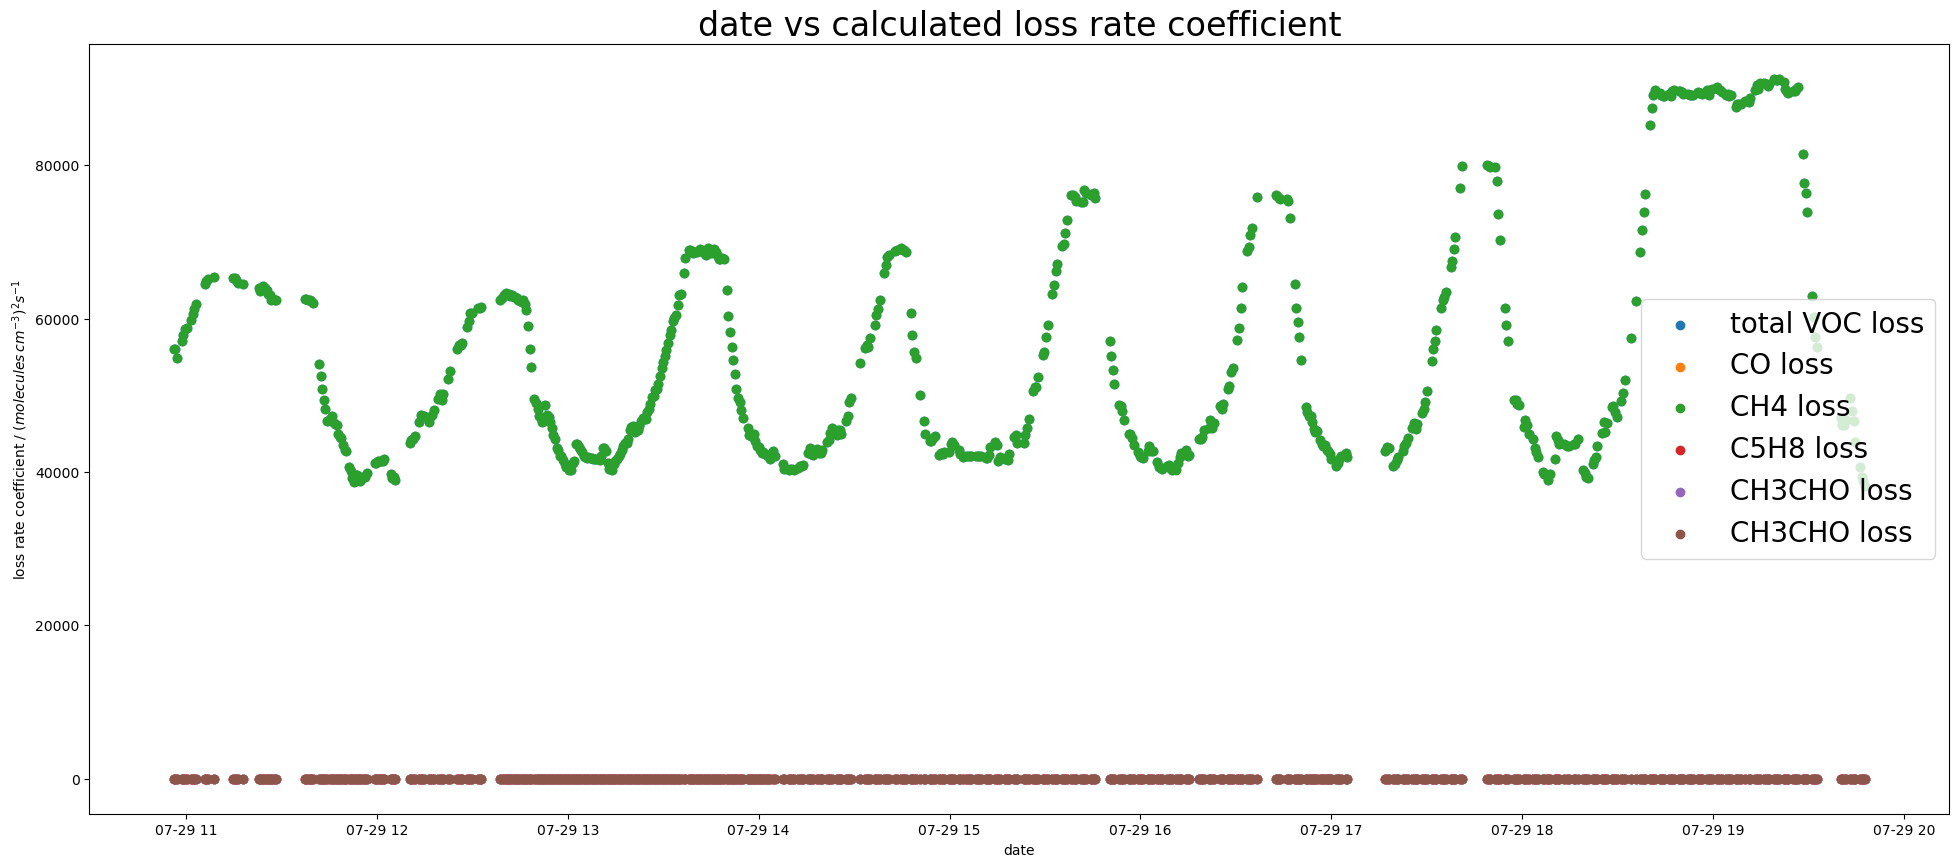

In [15]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize = (24, 10))
plt.rcParams.update({'font.size':20})
plt.scatter(df["UTC_Start_dt"][df["date"]< "2016-07-30"], total[df["date"]< "2016-07-30"], label = "total VOC loss")
plt.scatter(df["UTC_Start_dt"][df["date"]< "2016-07-30"], lossCO[df["date"]< "2016-07-30"], label = "CO loss")
plt.scatter(df["UTC_Start_dt"][df["date"]< "2016-07-30"], lossCH4[df["date"]< "2016-07-30"], label = "CH4 loss")
plt.scatter(df["UTC_Start_dt"][df["date"]< "2016-07-30"], lossC5H8[df["date"]< "2016-07-30"], label = "C5H8 loss")
plt.scatter(df["UTC_Start_dt"][df["date"]< "2016-07-30"], lossCH3CHO[df["date"]< "2016-07-30"], label = "CH3CHO loss")
plt.scatter(df["UTC_Start_dt"][df["date"]< "2016-07-30"], lossHCHO[df["date"]< "2016-07-30"], label = "CH3CHO loss")
plt.xlabel("date")
plt.ylabel("loss rate coefficient / $(molecules \: cm^{-3})^2 s^{-1}$")
plt.title("date vs calculated loss rate coefficient")
plt.legend(prop={'size':20})

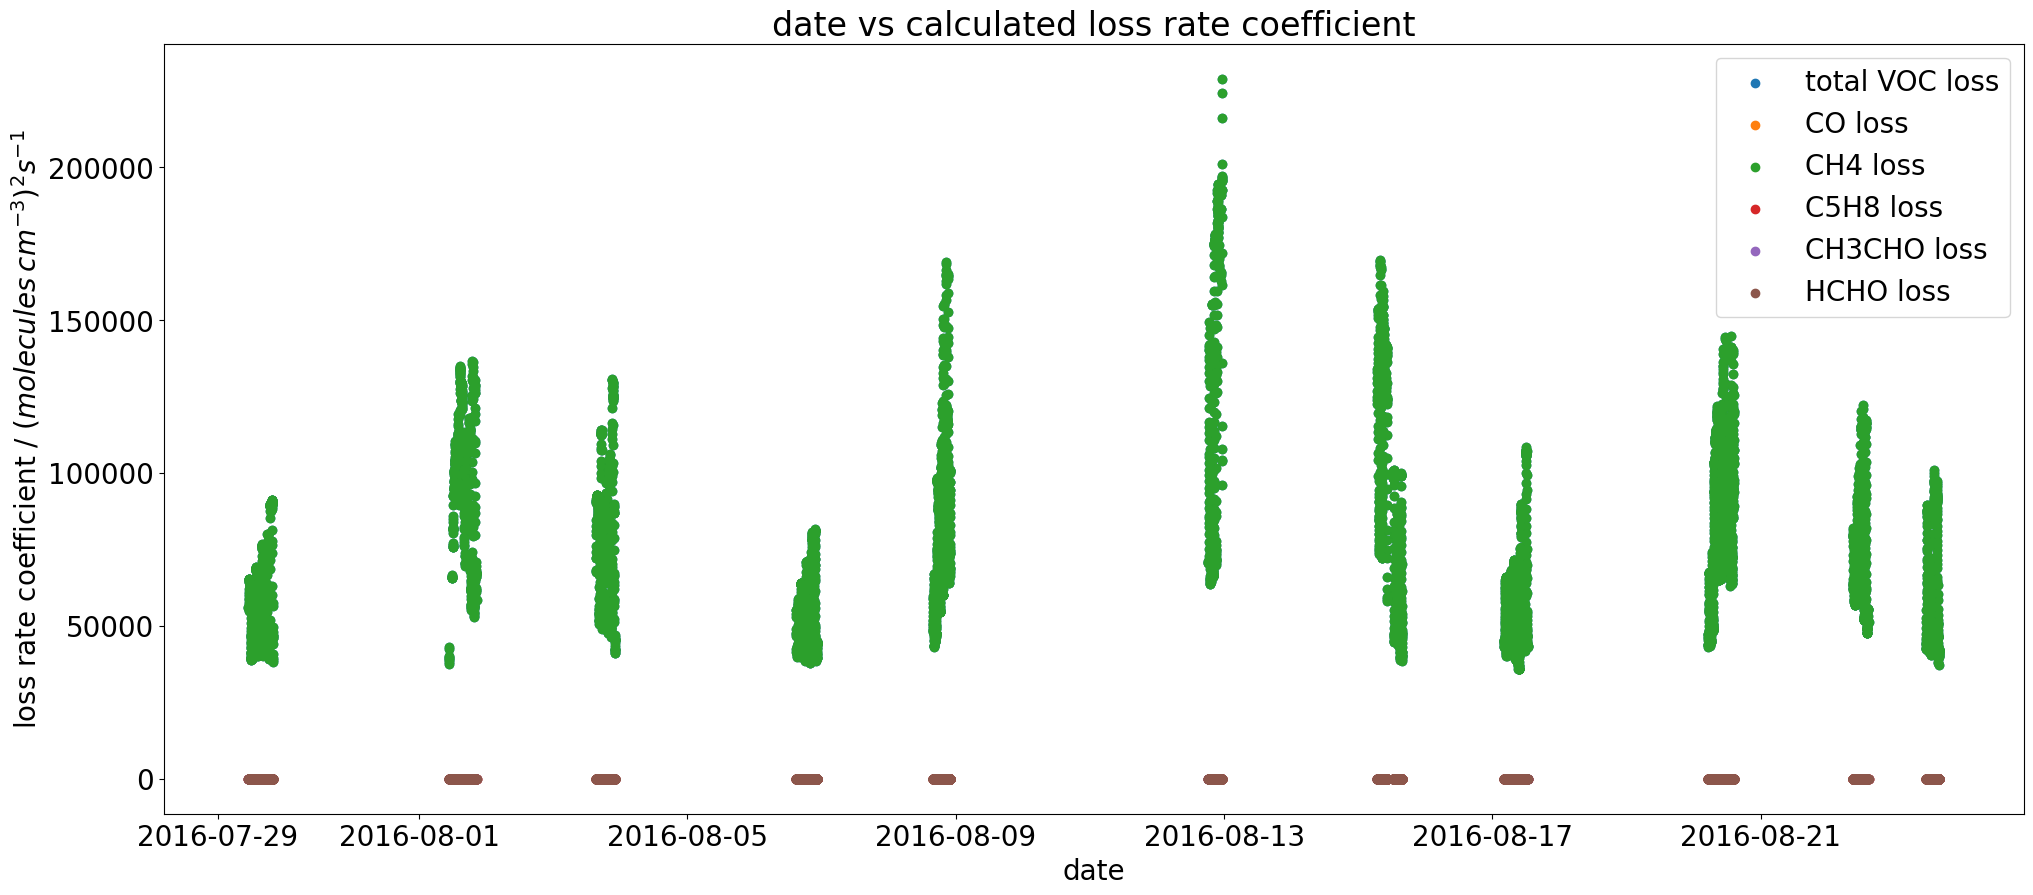

In [16]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize = (24, 10))
plt.scatter(df["UTC_Start_dt"], total, label = "total VOC loss")
plt.scatter(df["UTC_Start_dt"], lossCO, label = "CO loss")
plt.scatter(df["UTC_Start_dt"], lossCH4, label = "CH4 loss")
plt.scatter(df["UTC_Start_dt"], lossC5H8, label = "C5H8 loss")
plt.scatter(df["UTC_Start_dt"], lossCH3CHO, label = "CH3CHO loss")
plt.scatter(df["UTC_Start_dt"], lossHCHO, label = "HCHO loss")
plt.xlabel("date")
plt.ylabel("loss rate coefficient / $(molecules \: cm^{-3})^2 s^{-1}$")
plt.title("date vs calculated loss rate coefficient")
plt.legend()

CO and CH4 contributions appear much larger than the other VOCs

In [17]:
## Try adding to box model

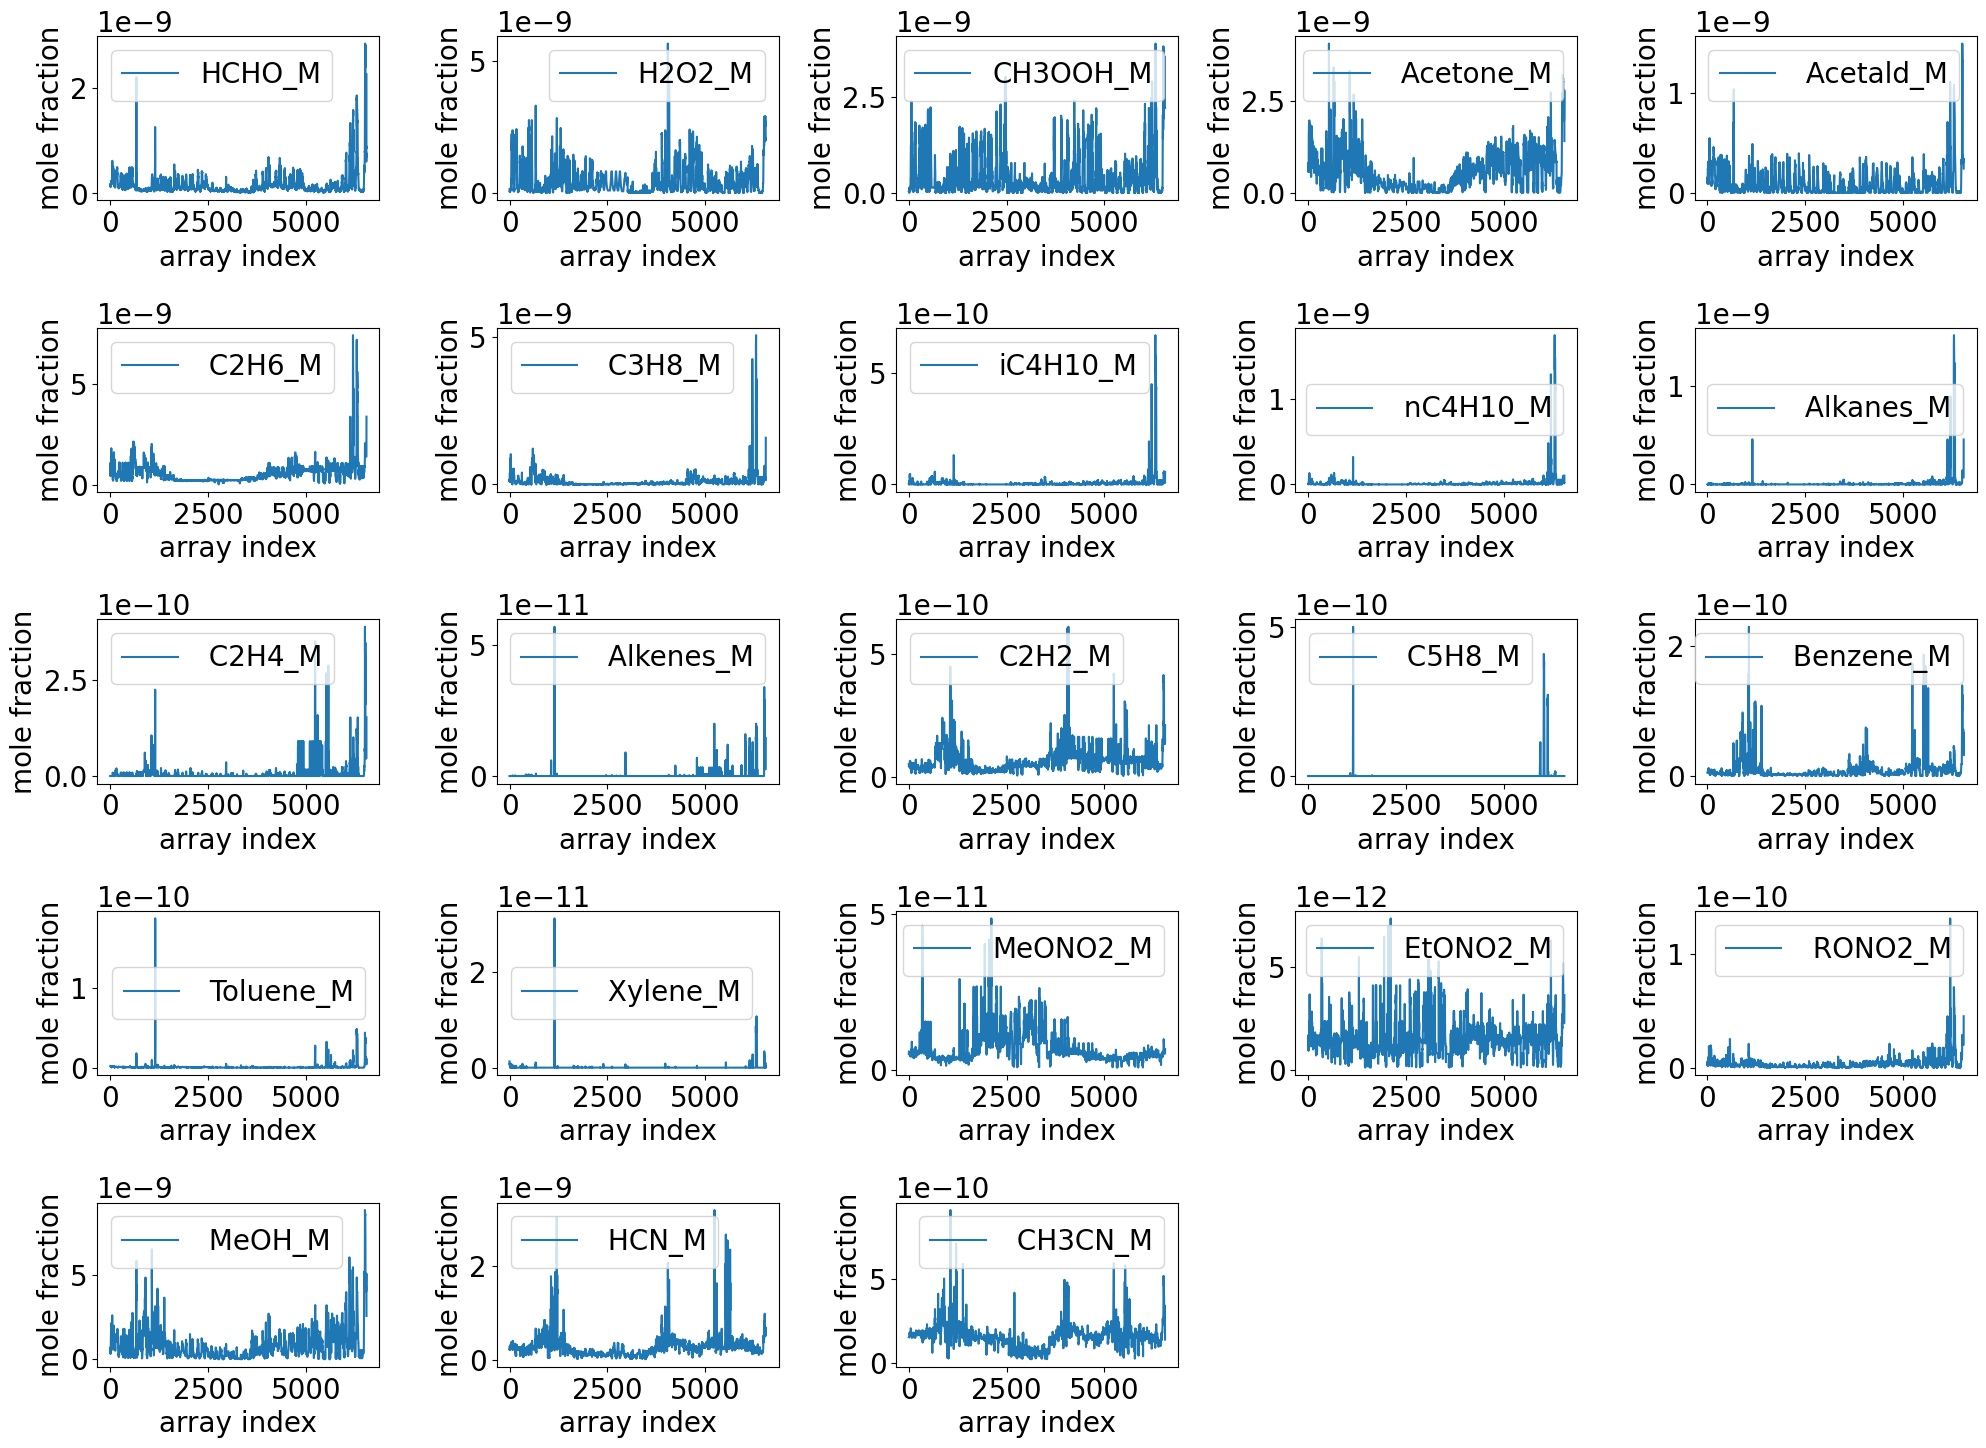

In [18]:

list_of_vars = ['HCHO_M', 'H2O2_M', 'CH3OOH_M', ' Acetone_M', ' Acetald_M', ' C2H6_M',
 ' C3H8_M', 'iC4H10_M', ' nC4H10_M', ' Alkanes_M', ' C2H4_M', ' Alkenes_M',
 'C2H2_M', ' C5H8_M', ' Benzene_M', ' Toluene_M', ' Xylene_M', 'MeONO2_M',
 ' EtONO2_M', ' RONO2_M', ' MeOH_M', ' HCN_M', ' CH3CN_M']
count = 1
plt.figure(figsize=(20, 20))
for var in list_of_vars:
    plt.subplot(7, 5, count)
    plt.plot(df[var], label = var) # As a default this just plots the points sequentially with x being the index in the df series and y being the concentration
    plt.legend()
    plt.xlabel("array index")
    plt.ylabel("mole fraction")
    if count < len(list_of_vars):
        count = count + 1
plt.tight_layout()
plt.show()